In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
df = pd.read_csv("../data/cleaned_data.csv")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sales,Year,Month,Day
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,1


In [3]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["InvoiceDate"].dtype

dtype('<M8[ns]')

### Customer Feature Engineering

In [4]:
snapshot_date = df["InvoiceDate"].max()
customer_data = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",
    "Sales": "sum"
})
customer_data.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]
customer_data.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,325,12,77556.46
12347.0,1,8,4921.53
12348.0,74,5,2019.40
12349.0,18,4,4428.69
12350.0,309,1,334.40


### Create Churn Label

In [5]:
customer_data["Churn"] = np.where(
    customer_data["Recency"] > 180,
    1,
    0
)
customer_data.head()

,Recency,Frequency,Monetary,Churn
Customer ID,,,,
12346.0,325,12,77556.46,1
12347.0,1,8,4921.53,0
12348.0,74,5,2019.40,0
12349.0,18,4,4428.69,0
12350.0,309,1,334.40,1


In [7]:
customer_data["Churn"].value_counts()

Churn
0    3480
1    2398
Name: count, dtype: int64

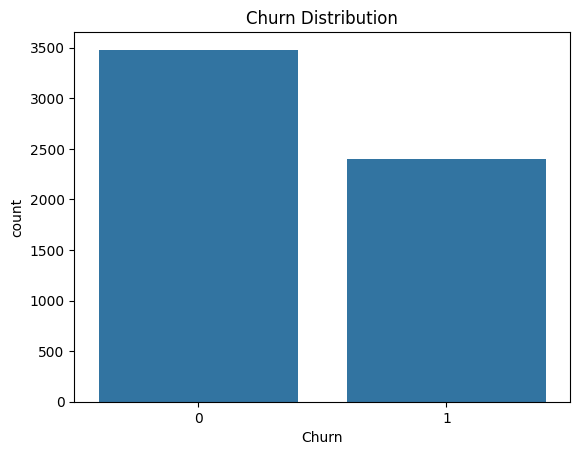

In [8]:
sns.countplot(
    x="Churn",
    data=customer_data
)
plt.title("Churn Distribution")
plt.show()

### Prepare Training Data

In [9]:
X = customer_data[
    ["Recency", "Frequency", "Monetary"]
]
y = customer_data["Churn"]

### Train Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)

(4702, 3)
(1176, 3)


### Logistic Regression Model

In [11]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)


### Logistic Regression Evaluation

In [12]:
print("Accuracy:",
      accuracy_score(y_test, lr_pred))
print("Precision:",
      precision_score(y_test, lr_pred))
print("Recall:",
      recall_score(y_test, lr_pred))
print("F1 Score:",
      f1_score(y_test, lr_pred))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


###  Random Forest Model

In [13]:
rf = RandomForestClassifier(
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [14]:
print("Accuracy:",
      accuracy_score(y_test, rf_pred))

print("Precision:",
      precision_score(y_test, rf_pred))

print("Recall:",
      recall_score(y_test, rf_pred))

print("F1 Score:",
      f1_score(y_test, rf_pred))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [15]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

cm

array([[696,   0],
       [  0, 480]])

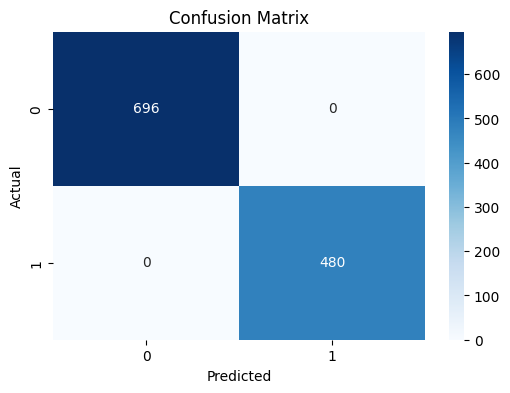

In [16]:
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Feature Importance

In [17]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})
importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
0,Recency,0.849627
1,Frequency,0.086406
2,Monetary,0.063968


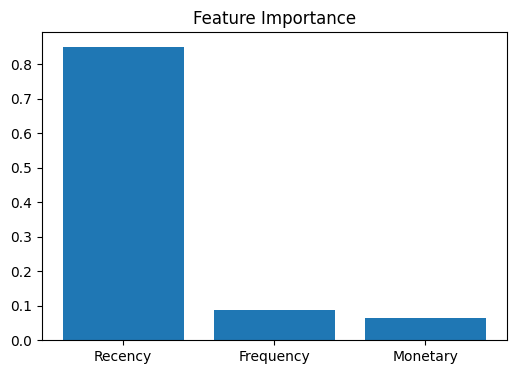

In [18]:
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
plt.figure(figsize=(6,4))
plt.bar(
    importance["Feature"],
    importance["Importance"]
)
plt.title("Feature Importance")

plt.show()

### Model Comparison

In [19]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,1.0
1,Random Forest,1.0


### Note

The churn label was generated using customer recency. Since recency is also included as a predictive feature, the model achieves near-perfect performance. In a real-world business environment, churn labels would be based on actual customer retention behavior over time.